### This is the main function for measuring a room impulse response


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import sys

In [2]:
tools_path = os.path.join(os.getcwd(), 'tools')
sys.path.append(tools_path)
from genChirp import gen_chirp
from padZeros import pad_zeros
from plot_tools import WaveVisualizer
from genMeasSig import gen_meas_sig
from getInverse import get_inverse
from getIR import get_ir

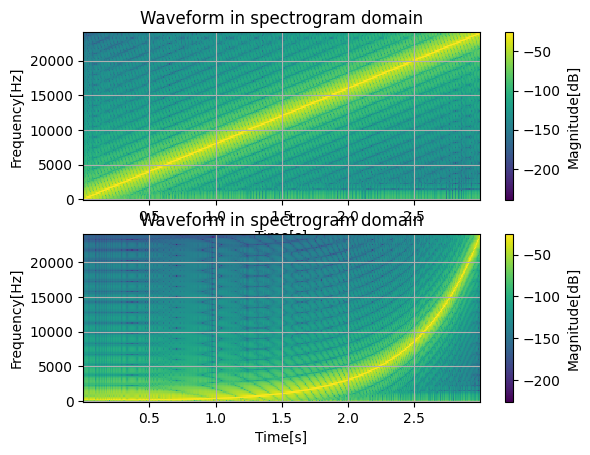

In [3]:
## 1.Generating a sweep signal (linear/exponential)
class config:

    fs = 48000
    f0 = 50
    T = 3
    f1 = fs/2
    phi0 = 0
    is_exp1 = True
    is_exp2 = False

expsig, t = gen_chirp(config.fs, config.f0, config.T, config.f1, config.phi0, config.is_exp1)
linsig, t = gen_chirp(config.fs, config.f0, config.T, config.f1, config.phi0, config.is_exp2)
# Plot signal
plt.subplot(211)
linsig_view = WaveVisualizer(linsig,config.fs,"Linear")
linsig_view.plot_spectrogram()
expsig_view = WaveVisualizer(expsig,config.fs,"Exponential")
plt.subplot(212)
expsig_view.plot_spectrogram()
plt.show()

/Users/wenmiao/Majority/Code/Github_tools/Tools/Room_Impulse_Response_Measurement/Python/tools/plot_tools.py:93: RuntimeWarning: divide by zero encountered in log10
  plt.pcolormesh(t, f, 10 * np.log10(Sxx))


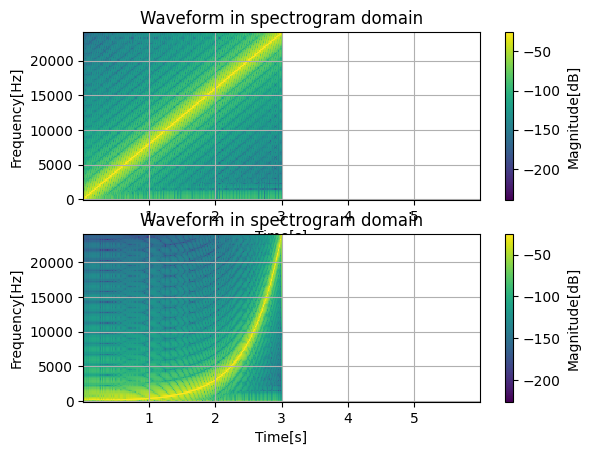

In [4]:
## 2.Generating the real measurement signal via applying windowningand zero-padding to the generated sweep signal
class config:
    fs = 48000
    f0 = 50
    Tsweep = 3
    f1 = fs/2
    T_silence = 3
    Tin = 2e-3
    Tout = 1e-4
    is_exp1 = True
    is_exp2 = False

expsig = gen_meas_sig(config.Tsweep, config.fs, config.f0, config.f1, config.T_silence, config.Tin, config.Tout, config.is_exp1)
linsig = gen_meas_sig(config.Tsweep, config.fs, config.f0, config.f1, config.T_silence, config.Tin, config.Tout, config.is_exp2)
# Plot signal
plt.subplot(211)
linsig_view = WaveVisualizer(linsig,config.fs,"Linear")
linsig_view.plot_spectrogram()
expsig_view = WaveVisualizer(expsig,config.fs,"Exponential")
plt.subplot(212)
expsig_view.plot_spectrogram()
plt.show()


/opt/anaconda3/envs/pytorch/lib/python3.11/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/anaconda3/envs/pytorch/lib/python3.11/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


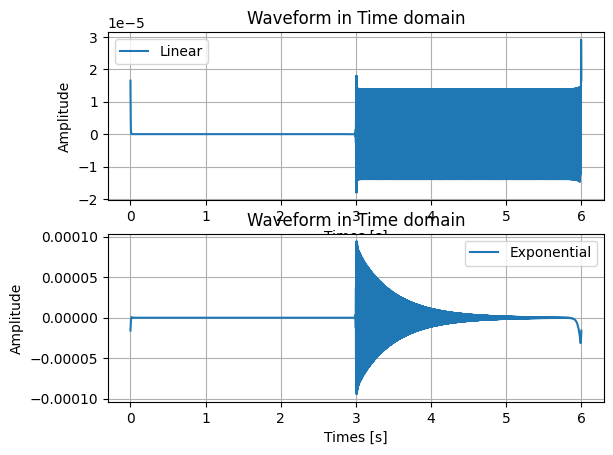

In [5]:
## 3.Create the inverse filter
hinv1, Hinv1= get_inverse(linsig)
hinv2, Hinv2= get_inverse(expsig)

plt.subplot(211)
h_view1 = WaveVisualizer(hinv1,config.fs,"Linear")
h_view1.plot_time_domain()
h_view2= WaveVisualizer(hinv2,config.fs,"Exponential")
plt.subplot(212)
h_view2.plot_time_domain()
plt.show()


In [6]:
## 4.Get the impulse response
h_lin = get_ir(linsig,Hinv1)
h_exp = get_ir(expsig, Hinv2)